In [1]:
import numpy as np
import matplotlib.pylab as plt
import sys
sys.path.append("..")

### Checking condition numbers and symmetry of the kernel
* If we use a DG polynomial basis of degree $p$, we would want to use the symmetric kernel $K^{(2p+1, p+1)}$, (e.g., $p=2 \to K^{(5, 3)}$)
* Then some problems may arise: We compute the B-spline coefficients $c_\gamma$ by solving a linear system. If this system becomes unstable, the $c_\gamma$ can become non-symmetric, which will affect the result.

Therefore, we check symmetry of the $c_\gamma$ and the condition number of the matrix $A$.

In [2]:
import numpy as np
import math
import scipy.linalg
from scipy.special import binom


def build_siac_system(moments: int, BSorder: int):
    """
    Build the c_gam system: A*cgam = b 
    """
    if moments % 2 != 0:
        raise ValueError("moments must be even.")

    RS = int(np.ceil(moments / 2))
    numspline = moments + 1

    A = np.zeros((numspline, numspline), dtype=float)

    for m in range(numspline):
        for gam in range(numspline):
            component = 0.0

            for n in range(m + 1):
                jsum = sum(
                    (-1) ** (j + BSorder - 1)
                    * binom(BSorder - 1, j)
                    * (
                        (j - 0.5 * (BSorder - 2)) ** (BSorder + n)
                        - (j - 0.5 * BSorder) ** (BSorder + n)
                    )
                    for j in range(BSorder)
                )

                component += (
                    binom(m, n)
                    * (gam - RS) ** (m - n)
                    * math.factorial(n)
                    / math.factorial(n + BSorder)
                    * jsum
                )

            A[m, gam] = component

    b = np.zeros(numspline, dtype=float)
    b[0] = 1.0

    return A, b, RS


def solve_siac_system(A, b):
    """
    Solve A c = b using LU factorization.
    """
    piv = scipy.linalg.lu_factor(A)
    cgam = scipy.linalg.lu_solve(piv, b)
    return cgam


def siac_cgam(moments: int, BSorder: int):
    """
    Compute SIAC coefficients c_gamma from the moment system.
    """
    A, b, _ = build_siac_system(moments, BSorder)
    return solve_siac_system(A, b)

def symmetry_error(cgam):
    """
    Max absolute symmetry defect:
        max |cgam[i] - cgam[-1-i]|
    """
    cgam = np.asarray(cgam, dtype=float)
    return np.max(np.abs(cgam - cgam[::-1]))

def relative_symmetry_error(cgam):
    cgam = np.asarray(cgam, dtype=float)
    denom = np.max(np.abs(cgam))
    if denom == 0:
        return 0.0
    return np.max(np.abs(cgam - cgam[::-1])) / denom

def relative_residual(A, cgam, b):
    r = A @ cgam - b
    nb = np.linalg.norm(b)
    if nb == 0:
        return np.linalg.norm(r)
    return np.linalg.norm(r) / nb

def siac_standard_kernel_diagnostics(p_values, print_coeffs=False):
    """
    Loop over DG degrees p and inspect the standard SIAC kernel:
        moments = 2*p
        BSorder = p + 1

    Prints:
    - condition number of A
    - symmetry defect of cgam
    - relative residual of the solve
    - max coefficient size

    Parameters
    ----------
    p_values : iterable of int
        DG degrees to test.
    print_coeffs : bool
        If True, also print cgam for each p.

    Returns
    -------
    results : list of dict
        Diagnostic data for each p.
    """
    results = []

    print("\n" + "=" * 120)
    print("SIAC standard-kernel diagnostics")
    print("=" * 120)
    print(
        f"{'p':>3} {'moments':>8} {'BSorder':>8} "
        f"{'cond(A)':>16} {'sym abs':>14} {'sym rel':>14} "
        f"{'rel residual':>16} {'max|c|':>14}"
    )
    print("-" * 120)

    for p in p_values:
        moments = 2 * p
        BSorder = p + 1

        A, b, RS = build_siac_system(moments, BSorder)
        cgam = solve_siac_system(A, b)

        condA = np.linalg.cond(A)
        sym_abs = symmetry_error(cgam)
        sym_rel = relative_symmetry_error(cgam)
        rel_res = relative_residual(A, cgam, b)
        max_c = np.max(np.abs(cgam))

        results.append({
            "p": p,
            "moments": moments,
            "BSorder": BSorder,
            "RS": RS,
            "condA": condA,
            "sym_abs": sym_abs,
            "sym_rel": sym_rel,
            "rel_residual": rel_res,
            "max_abs_cgam": max_c,
            "cgam": cgam,
        })

        print(
            f"{p:3d} {moments:8d} {BSorder:8d} "
            f"{condA:16.6e} {sym_abs:14.6e} {sym_rel:14.6e} "
            f"{rel_res:16.6e} {max_c:14.6e}"
        )

        if print_coeffs:
            print(f"  cgam = {cgam}")

    print("-" * 120)
    return results

In [3]:

def summarize_siac_diagnostics(results, cond_warn=1e12, sym_warn=1e-10, res_warn=1e-10):
    print("\nSummary warnings:")
    any_warn = False

    for row in results:
        flags = []
        if row["condA"] > cond_warn:
            flags.append(f"cond(A)>{cond_warn:.1e}")
        if row["sym_abs"] > sym_warn:
            flags.append(f"sym_abs>{sym_warn:.1e}")
        if row["rel_residual"] > res_warn:
            flags.append(f"rel_res>{res_warn:.1e}")

        if flags:
            any_warn = True
            print(f"p={row['p']:2d}: " + ", ".join(flags))

    if not any_warn:
        print("No warnings triggered.")
        
results = siac_standard_kernel_diagnostics(
    p_values=range(0, 13),
    print_coeffs=False
)
summarize_siac_diagnostics(results)

#  6       12        7     7.394128e+10   1.517892e-10   5.220349e-11     8.029979e-10   2.907646e+00


SIAC standard-kernel diagnostics
  p  moments  BSorder          cond(A)        sym abs        sym rel     rel residual         max|c|
------------------------------------------------------------------------------------------------------------------------
  0        0        1     1.000000e+00   0.000000e+00   0.000000e+00     0.000000e+00   1.000000e+00
  1        2        2     3.802907e+00   0.000000e+00   0.000000e+00     3.083953e-18   1.166667e+00
  2        4        3     7.965273e+01   5.551115e-17   4.064890e-17     2.708404e-16   1.365625e+00
  3        6        4     5.944687e+03   1.110223e-16   6.866797e-17     1.253926e-15   1.616799e+00
  4        8        5     8.651228e+05   1.676437e-14   8.643392e-15     4.929471e-14   1.939559e+00
  5       10        6     2.070874e+08   1.709743e-13   7.248571e-14     6.949268e-12   2.358732e+00
  6       12        7     7.394128e+10   3.643752e-12   1.253162e-12     2.300264e-10   2.907646e+00
  7       14        8     3.688779e+1

In [4]:
from src.siac_modal import eval_orthonormal_legendre_1d
from numpy.polynomial.legendre import leggauss
# checking orthonormality of basis

p = 5
q, w = leggauss(20)     # sufficiently high order

phi = eval_orthonormal_legendre_1d(q, p)   # shape (p+1, nq)
M = np.zeros((p+1, p+1))

for i in range(p+1):
    for j in range(p+1):
        M[i, j] = np.sum(w * phi[i, :] * phi[j, :])

identity = np.eye(p+1, p+1)

print(f"Max error: {np.max(np.abs(M-identity))}")

Max error: 7.549516567451064e-15


### 1D reproduction testing

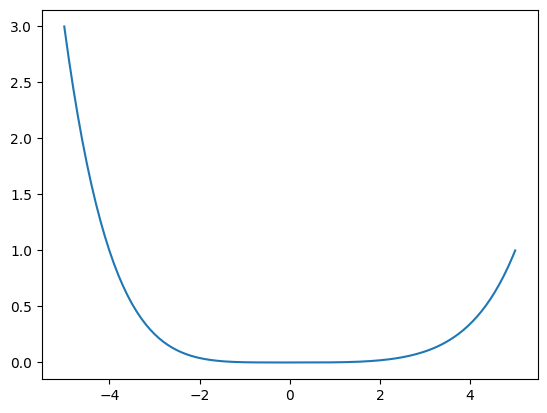

In [5]:
def exact_poly1d_scaled(x, degree=4, xlim=(-1,1)):
    x = np.asarray(x)
    
    # map to [-1,1]
    xhat = 2*(x - xlim[0]) / (xlim[1] - xlim[0]) - 1
    
    poly = 0.0
    
    if degree >= 1:
        poly -= xhat**1
    if degree >= 2:
        poly += xhat**2
    if degree >= 3:
        poly -= xhat**3
    if degree >= 4:
        poly = xhat**4
    if degree >= 5:
        poly -= xhat**5
    if degree >= 6:
        poly += xhat**6
    return poly
   
xlim = (-5, 5) 
x_vec = np.linspace(xlim[0], xlim[1], 201)
plt.plot(x_vec, exact_poly1d_scaled(x_vec, degree=6, xlim=xlim))
plt.show()



In [6]:
import numpy as np
from src.research_utils_1d import(
    local_cell_center_nodes_1d, 
    build_mesh_1d, 
    build_grid_from_local_nodes_1d, 
    nodal_to_modal_1d, 
    eval_dg_modal_local_nodes_1d, 
    apply_siac_modal_dg_local_nodes_1d, 
    trim_valid_siac_region_1d
)

def run_poly_reproduction_test_1d(
    poly_degrees=(2, 4, 5),
    p_values=(0, 1, 2, 3, 4, 5),
    K=16,
    xlim=(-5, 5),
    n_eval_factor=8,
    siac_mode="standard",
):
    """
    Test 1D polynomial reproduction for nodal -> modal DG and SIAC.

    Parameters
    ----------
    poly_degrees : iterable of int
        Exact polynomial degrees to test.
    p_values : iterable of int
        DG polynomial degrees to test.
    K : int
        Number of DG elements.
    xlim : tuple
        Domain limits.
    n_eval_factor : int
        Number of fine evaluation points per local DG node count,
        i.e. n_eval = n_eval_factor * (p+1).
    siac_mode : str
        Currently only "standard":
            moments = 2*p
            BSorder = p+1

    Returns
    -------
    all_results : dict
        Dictionary keyed by polynomial degree, each containing a list of results.
    """
    all_results = {}

    xmin, xmax = xlim

    for poly_deg in poly_degrees:
        results = []

        for p in p_values:
            p = int(p)
            order = p + 1
            N = K * order

            if siac_mode == "standard":
                moments = 2 * p
                BSorder = p + 1
            else:
                raise ValueError(f"Unknown siac_mode: {siac_mode}")

            # -----------------------------
            # 1. Build mesh and original image grid
            # -----------------------------
            orig_nodes = local_cell_center_nodes_1d(nloc=order)

            mesh = build_mesh_1d(K, domain=xlim)
            grid, grid_blocks = build_grid_from_local_nodes_1d(
                mesh, eval_nodes=orig_nodes, return_blocks=True
            )

            # exact sampled data on nodal grid
            exact_data = exact_poly1d_scaled(x=grid, degree=poly_deg, xlim=xlim)
            Unode = exact_poly1d_scaled(x=grid_blocks, degree=poly_deg, xlim=xlim)

            # -----------------------------
            # 2. Build DG representation
            # -----------------------------
            dg = nodal_to_modal_1d(Unode, mesh=mesh, p=p)

            # -----------------------------
            # 3. Fine local nodes per element
            # -----------------------------
            n_eval = n_eval_factor * order
            nodes_fine = local_cell_center_nodes_1d(n_eval)

            assert int(n_eval) == int(len(nodes_fine)), (
                "ValueError: length of nodes_fine does not equal "
                "number of fine evaluation points (n_eval)"
            )

            # -----------------------------
            # 4. Build global fine grid
            # -----------------------------
            grid_fine = build_grid_from_local_nodes_1d(
                mesh, eval_nodes=nodes_fine, return_blocks=False
            )

            # -----------------------------
            # 5. Evaluate exact, DG, SIAC
            # -----------------------------
            U_exact = exact_poly1d_scaled(x=grid_fine, degree=poly_deg, xlim=xlim)

            U_dg = eval_dg_modal_local_nodes_1d(dg, eval_nodes=nodes_fine)

            quad_order = 2*p + 4
            U_siac = apply_siac_modal_dg_local_nodes_1d(
                dg,
                moments=moments,
                BSorder=BSorder,
                eval_nodes=nodes_fine,
                quad_order=quad_order
            )

            # -----------------------------
            # 6. Trim interior for SIAC comparison
            # -----------------------------
            exact_trim = trim_valid_siac_region_1d(
                arr=U_exact, n_eval=n_eval, moments=moments, BSorder=BSorder
            )

            dg_trim = trim_valid_siac_region_1d(
                arr=U_dg, n_eval=n_eval, moments=moments, BSorder=BSorder
            )

            siac_trim = trim_valid_siac_region_1d(
                arr=U_siac, n_eval=n_eval, moments=moments, BSorder=BSorder
            )

            # -----------------------------
            # 7. Errors (interior only comparison)
            # -----------------------------
            err_dg = dg_trim - exact_trim
            err_siac = siac_trim - exact_trim

            dg_max = np.max(np.abs(err_dg))
            dg_rel = np.linalg.norm(err_dg) / np.linalg.norm(exact_trim)

            siac_max = np.max(np.abs(err_siac))
            siac_rel = np.linalg.norm(err_siac) / np.linalg.norm(exact_trim)

            results.append({
                "poly_deg": poly_deg,
                "p": p,
                "K": K,
                "N": N,
                "moments": moments,
                "BSorder": BSorder,
                "DG_max_err": dg_max,
                "DG_rel_err": dg_rel,
                "SIAC_max_err": siac_max,
                "SIAC_rel_err": siac_rel,
            })

        all_results[poly_deg] = results

    return all_results

def run_single_poly_reproduction_test_1d(
    poly_deg,
    p_values=(0, 1, 2, 3, 4, 5),
    K=16,
    xlim=(-5, 5),
    n_eval_factor=8,
):
    return run_poly_reproduction_test_1d(
        poly_degrees=(poly_deg,),
        p_values=p_values,
        K=K,
        xlim=xlim,
        n_eval_factor=n_eval_factor,
    )

In [7]:
def print_poly_reproduction_results_1d(results_dict, poly_deg, tol=1e-12):
    """
    Pretty-print 1D polynomial reproduction results for one exact polynomial degree.

    Parameters
    ----------
    results_dict : dict
        Output from run_single_poly_reproduction_test_1d or run_poly_reproduction_test_1d.
    poly_deg : int
        Exact polynomial degree to print.
    tol : float
        Tolerance used for "machine precision" style checks.
    """
    rows = results_dict[poly_deg]

    print("\n" + "=" * 130)
    print(f"1D reproduction results for exact polynomial degree {poly_deg}")
    print("=" * 130)
    print(
        f"{'p':>3} {'K':>5} {'N':>6} "
        f"{'DG max':>14} {'DG rel':>14} {'DG exact?':>10} {'DG expected?':>13} "
        f"{'SIAC max':>14} {'SIAC rel':>14} {'SIAC exact?':>12}"
    )
    print("-" * 130)

    for row in rows:
        p = row["p"]
        K = row["K"]
        N = row["N"]

        dg_max = row["DG_max_err"]
        dg_rel = row["DG_rel_err"]
        siac_max = row["SIAC_max_err"]
        siac_rel = row["SIAC_rel_err"]

        dg_exact = dg_max < tol
        siac_exact = siac_max < tol

        # For DG, exact reproduction is expected once p >= poly_deg
        dg_expected = (p >= poly_deg)

        print(
            f"{p:3d} {K:5d} {N:6d} "
            f"{dg_max:14.6e} {dg_rel:14.6e} {str(dg_exact):>10} {str(dg_expected):>13} "
            f"{siac_max:14.6e} {siac_rel:14.6e} {str(siac_exact):>12}"
        )

    print("-" * 130)

    # first p where DG becomes exact
    dg_exact_ps = [row["p"] for row in rows if row["DG_max_err"] < tol]
    siac_exact_ps = [row["p"] for row in rows if row["SIAC_max_err"] < tol]

    if dg_exact_ps:
        print(f"DG first reaches |error| < {tol:.1e} at p = {dg_exact_ps[0]}")
    else:
        print(f"DG never reaches |error| < {tol:.1e} in the tested p-range.")

    if siac_exact_ps:
        print(f"SIAC first reaches |error| < {tol:.1e} at p = {siac_exact_ps[0]}")
    else:
        print(f"SIAC never reaches |error| < {tol:.1e} in the tested p-range.")

In [8]:
poly_deg = 2

# DG stuff
p_values = np.arange(5+1)       # Above p = 5, the condition number of A and symmetry of the c_gammas affect the result too much
p_max = np.max(p_values)
order_max = p_max + 1
halfker_max = int(np.ceil((2*p_max + p_max + 1)/2))
K = 64


results = run_single_poly_reproduction_test_1d(
    poly_deg=poly_deg,
    p_values=p_values,
    K=K,
    xlim=(-5, 5),
    n_eval_factor=2**4,
)

print_poly_reproduction_results_1d(results, poly_deg=poly_deg, tol=1e-12)


1D reproduction results for exact polynomial degree 2
  p     K      N         DG max         DG rel  DG exact?  DG expected?       SIAC max       SIAC rel  SIAC exact?
----------------------------------------------------------------------------------------------------------------------------------
  0    64     64   4.278660e-02   1.931821e-02      False         False   2.431870e-04   2.549765e-04        False
  1    64    128   1.680851e-04   1.126967e-04      False         False   2.034505e-05   3.041444e-05        False
  2    64    192   6.661338e-16   2.381933e-16       True          True   8.881784e-16   2.178349e-16         True
  3    64    256   6.661338e-16   2.180077e-16       True          True   1.110223e-15   3.104666e-16         True
  4    64    320   1.554312e-15   3.138935e-16       True          True   1.554312e-15   6.117383e-16         True
  5    64    384   2.442491e-15   4.856705e-16       True          True   8.215650e-15   8.553704e-15         True
---------

**Theoretical reproduction thresholds (standard SIAC kernel, moments = 2p, BSorder = p+1)**

| Exact polynomial degree $k$ | Minimum DG degree for exact DG reproduction $p_{\mathrm{DG}}$ | Minimum DG degree for exact SIAC reproduction $p_{\mathrm{DG}}$ |
|---|---:|---:|
| 1 | 1 | 0 |
| 2 | 2 | 1 |
| 3 | 3 | 1 |
| 4 | 4 | 2 |
| 5 | 5 | 2 |
| 6 | 6 | 3 |